In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd



In [20]:
df = pd.read_csv('../expanded_water_usage.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
#df = df.set_index('timestamp')
df.head()

,timestamp,water_usage
0,2010-01-01 00:00:00,5.524019
1,2010-01-01 01:00:00,5.400714
2,2010-01-01 02:00:00,5.308263
3,2010-01-01 03:00:00,5.308263
4,2010-01-01 04:00:00,5.924607


In [25]:
daily_sum = df.groupby(pd.Grouper(key='timestamp', freq='D'))['water_usage'].sum().reset_index()

daily_sum.head()

,timestamp,water_usage
0,2010-01-01,206.097759
1,2010-01-02,286.065702
2,2010-01-03,263.373174
3,2010-01-04,211.942952
4,2010-01-05,227.627559


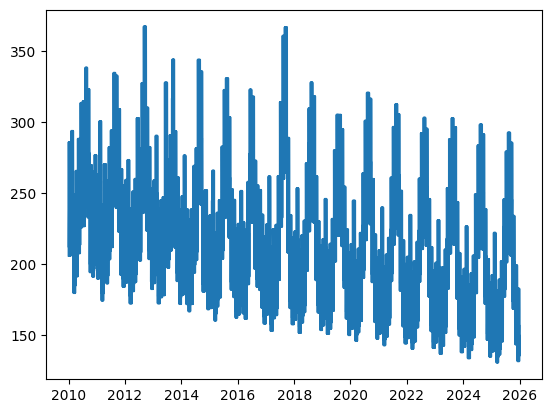

In [13]:
plt.plot(daily_sum.index, daily_sum.values)

In [34]:
data_2011 = df[(df['timestamp'].dt.year == 2011)]
daily_sum = data_2011.groupby(pd.Grouper(key='timestamp', freq='D'))['water_usage'].sum().reset_index()
monthly_avg = daily_sum.groupby(pd.Grouper(key='timestamp', freq='M'))['water_usage'].mean().reset_index()


/tmp/ipykernel_88757/1763186736.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = daily_sum.groupby(pd.Grouper(key='timestamp', freq='M'))['water_usage'].mean().reset_index()


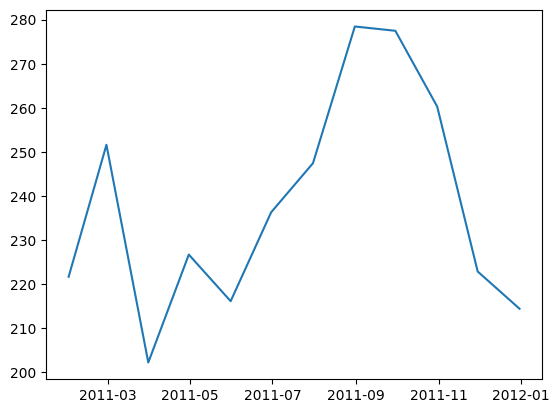

In [35]:
plt.plot(monthly_avg['timestamp'], monthly_avg['water_usage'])


In [ ]:
def aggregate_projections(data, date, type):
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    if type == "daily":
        date = date.date()
        daily_data = data[data['timestamp'].dt.date == date]
        return daily_data
    elif type == "monthly":
        monthly_data = data[(data['timestamp'].dt.year == date.year) & (data['timestamp'].dt.month == date.month)]
        numeric_columns = monthly_data.select_dtypes(include=[np.number]).columns

        return monthly_data.groupby(pd.Grouper(key='timestamp', freq='D'))[numeric_columns].sum().reset_index()
    elif type == "yearly":
        yearly_data = data[(data['timestamp'].dt.year == date.year)]
        numeric_columns = yearly_data.select_dtypes(include=[np.number]).columns
        yearly_data.groupby(pd.Grouper(key='timestamp', freq='D'))[numeric_columns].sum().reset_index()
        return yearly_data.groupby(pd.Grouper(key='timestamp', freq='M'))[numeric_columns].mean().reset_index()

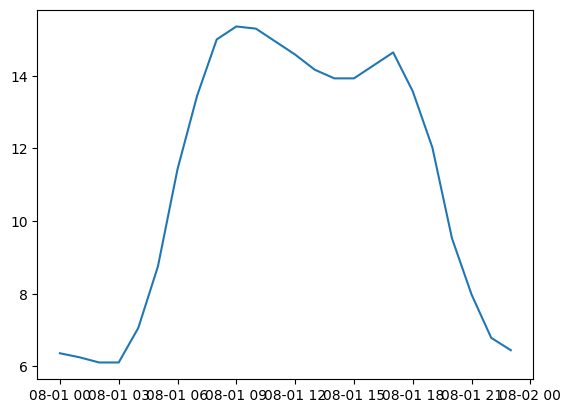

In [74]:
data = aggregate_projections(df, pd.to_datetime("2012-08-01"), "daily")
plt.plot(data['timestamp'], data['water_usage'])